# NNLS and MADCO Initialisation

This notebook compares two ways of constructing an initial tissue-compartment model from the measured signal.

## NNLS

For each selected voxel, NNLS estimates a non-negative spectrum `f` on the `(D, T2)` grid by solving

`minimize ||A f - y||^2 subject to f >= 0`,

where `A` is the signal dictionary and `y` is the measured voxel signal. The estimated spectrum is normalised, and the spectra from the selected voxels are averaged to form a representative tissue spectrum.

The representative spectrum is then clustered into `K` compartments using weighted k-means. Each cluster is converted into a Gaussian-shaped compartment, and the resulting compartment matrix is projected into the reduced SVD basis used by the optimiser.

## MADCO

MADCO uses the same overall pipeline, but adds marginal constraints to the spectrum fit. For each voxel, it first estimates:

- a diffusion marginal from measurements at the shortest echo times; and
- a T2 marginal from measurements at the lowest diffusion weight.

It then starts from the NNLS solution and solves a non-negative soft-constrained problem:

`data-fitting error + regularisation weight * marginal-matching error`.

The fitted spectrum is therefore encouraged to reproduce both the measured signal and the separately estimated diffusion and T2 marginals. These spectra are averaged, clustered, converted to Gaussian compartments, and projected into the SVD basis in the same way as for NNLS.

In short, NNLS uses only the full signal fit, whereas MADCO uses the full signal fit plus marginal information. Both methods provide initial values for the same downstream optimisation.

In [9]:
from create_grid import apply_SVD_to_A, create_A_matrix, create_M0_true, create_W_true, create_DT2_grid, create_gaussian_compartments, create_signal
from optimiser_alpha_gamma import *
from plotting import *
import numpy as np 
import matplotlib.pyplot as plt



Define grid

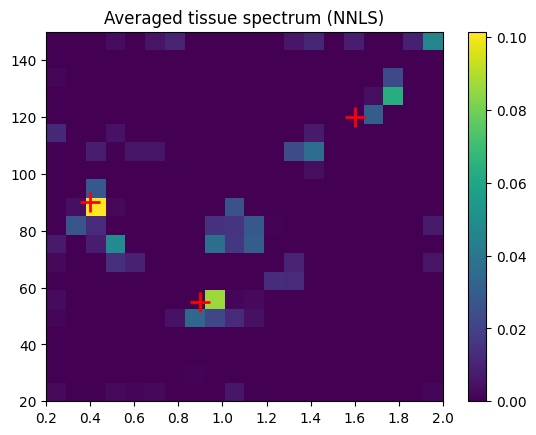

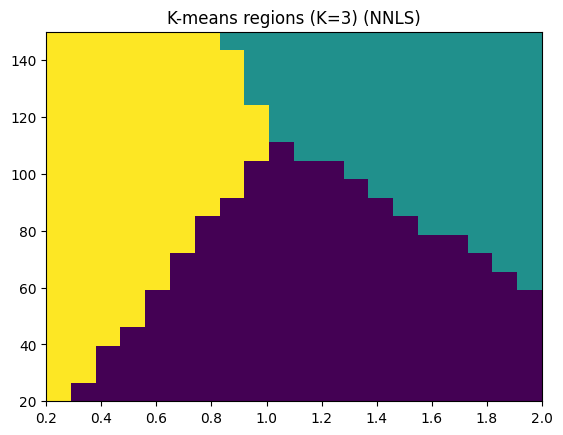

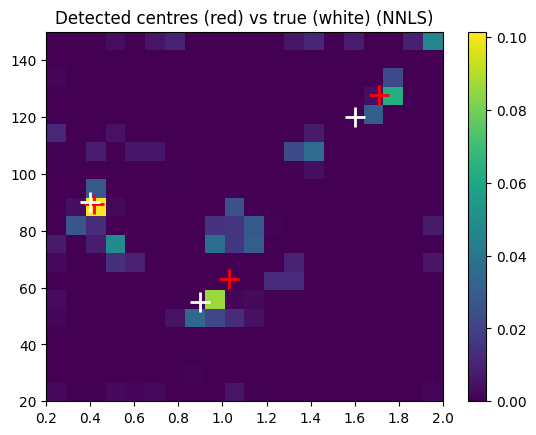

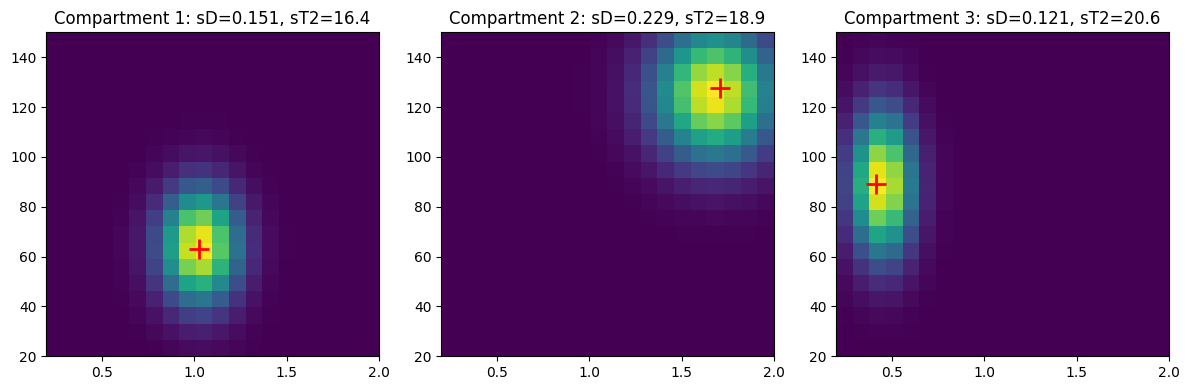

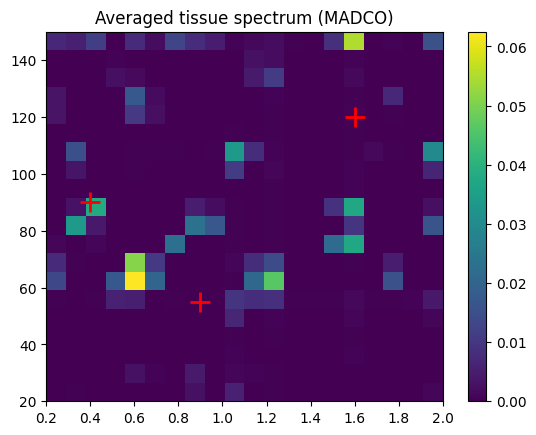

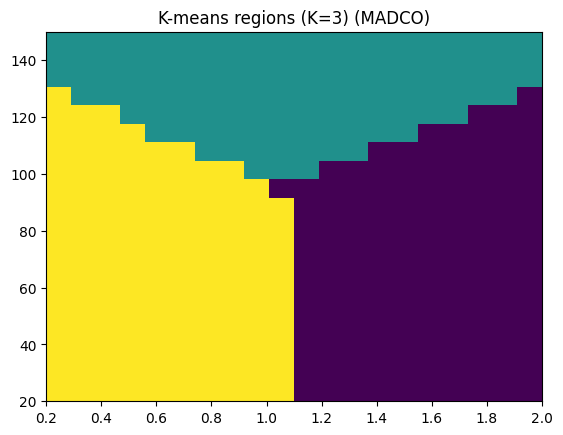

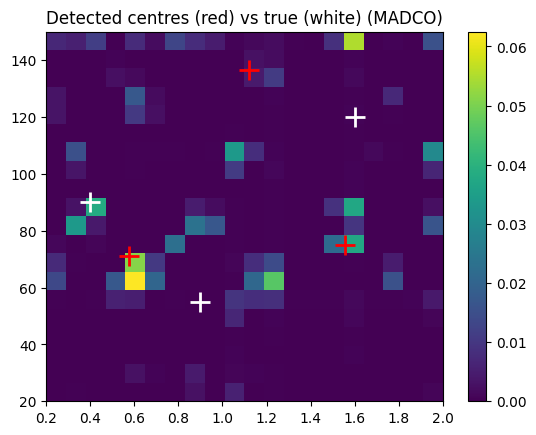

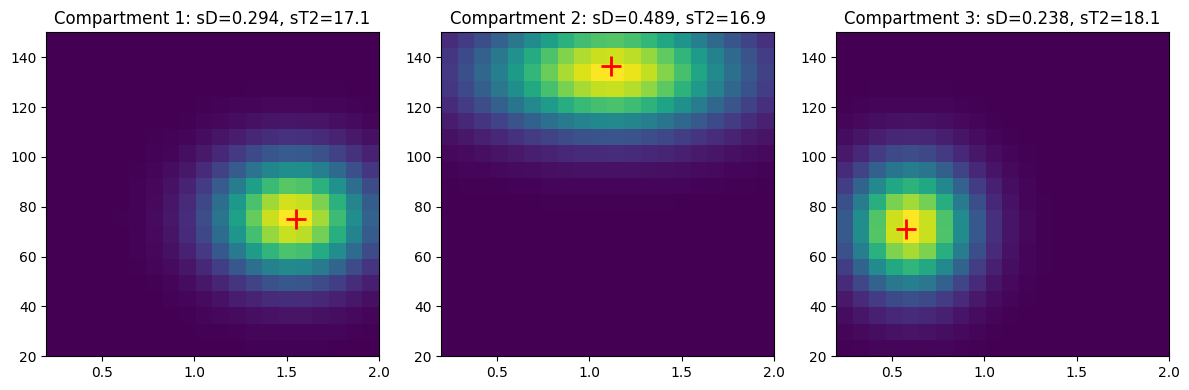

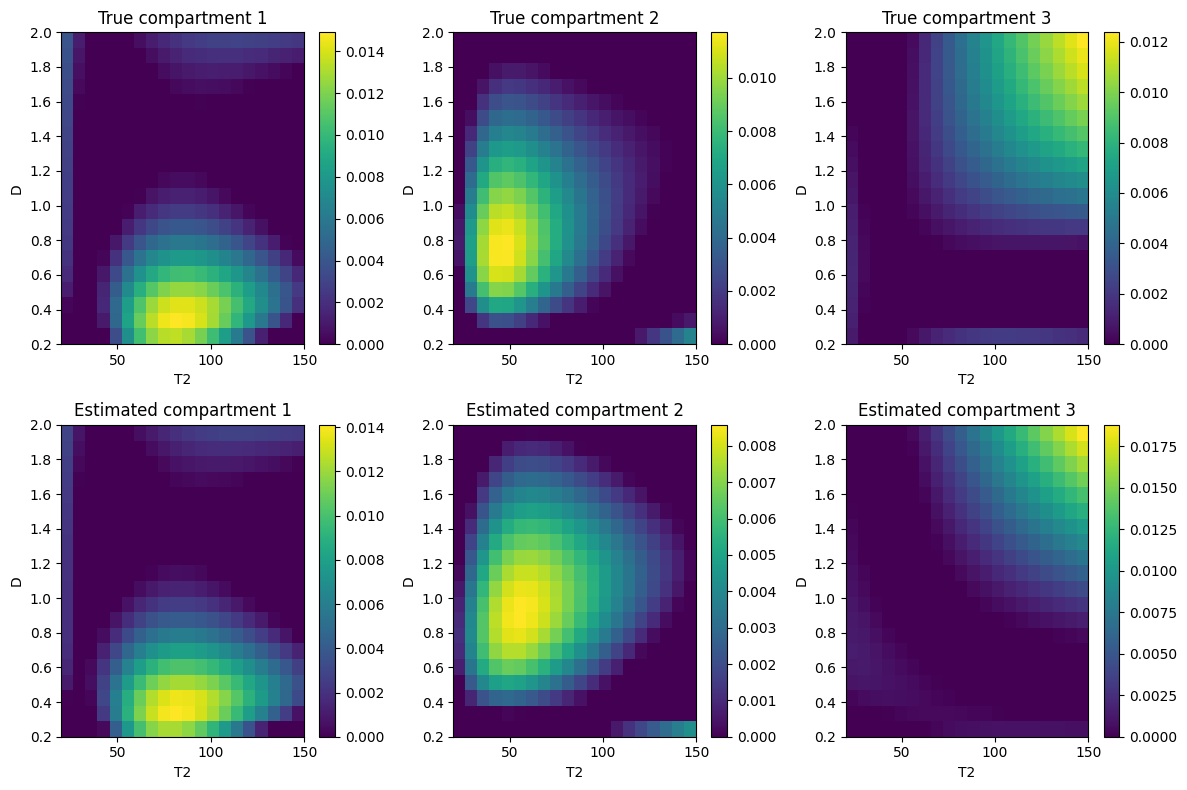

In [10]:
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.2, 20.0, 2.0, 150.0, 20, 20
Bmin, Bmax, nB, TEmin, TEmax, nTE = 0.0, 4.0, 20, 20.0, 180.0, 20
R, K = 10, 3
alpha_true = 1.5
n_voxels = 300
sigma_true = 0.002
eps = 0.0001

D_means = [0.4, 0.9, 1.6]
D_stds = [0.10, 0.12, 0.16]
T2_means = [90, 55, 120]
T2_stds = [15, 10, 18]

np.random.seed(1)
rng = np.random.default_rng(1)

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)     
T2_vals = np.linspace(T2min, T2max, nT2) 

b_vals = np.linspace(Bmin, Bmax, nB)    
TE_vals = np.linspace(TEmin, TEmax, nTE)  
A = create_A_matrix(D_grid, T2_grid, Bmin, Bmax, nB, TEmin, TEmax, nTE)
U, s, V_mat = apply_SVD_to_A(A, R)

C_true = create_gaussian_compartments(D_grid, T2_grid, D_means, D_stds, T2_means, T2_stds)
W_true = create_W_true(K, n_voxels, alpha_true, rng)
M0_true = create_M0_true(0.7, 1.3, n_voxels, rng)
Y = create_signal(A, C_true, W_true, M0_true, sigma_true, rng)
C_small_true = np.diag(s) @ V_mat.T @ C_true

sigma2_true = sigma_true ** 2

lam_true = define_initial_lambda(C_small_true, R, K)
W0, M0_init = define_initial_W_and_m(K, n_voxels, rng)
voxel_idx = [10, 20, 30, 40, 50, 60, 70]

C_small_init= define_initial_C_small(Y,U,W0,M0_init,K)

C_small_init_nnls, tissue_spectrum_nnls, labels_nnls, compartment_centers_nnls, compartment_widths_nnls, C_new_gauss_nnls = define_initial_C_small_NNLS(
    Y, A, s, V_mat, voxel_idx, K, D_vals, T2_vals, Dmin, Dmax, T2min, T2max, nD, nT2,
    return_diagnostics=True,
)

C_small_init_madco, tissue_spectrum_madco, labels_madco, compartment_centers_madco, compartment_widths_madco, C_new_gauss_madco = define_initial_C_small_MADCO(
    Y, A, s, V_mat, voxel_idx, K, D_vals, T2_vals, b_vals, TE_vals,
    Dmin, Dmax, T2min, T2max, nB, nTE, nD, nT2,
    return_diagnostics=True,
)

plot_init_diagnostics(
    tissue_spectrum_nnls, labels_nnls, compartment_centers_nnls, K, nD, nT2, D_vals, T2_vals,
    D_means=D_means, T2_means=T2_means,
    compartment_widths=compartment_widths_nnls, C_new_gauss=C_new_gauss_nnls,
    method_label="NNLS",
)

plot_init_diagnostics(
    tissue_spectrum_madco, labels_madco, compartment_centers_madco, K, nD, nT2, D_vals, T2_vals,
    D_means=D_means, T2_means=T2_means,
    compartment_widths=compartment_widths_madco, C_new_gauss=C_new_gauss_madco,
    method_label="MADCO",
)


C_init_full = estimate_C(V_mat, s, C_small_init_nnls)
C_true_full = estimate_C(V_mat, s, C_small_true)
plot_compartment_comparison(C_true_full, C_init_full, K, nD, nT2, D_vals, T2_vals)



True weights for this voxel: [0.43159519 0.18325337 0.38515144]
True compartment (D,T2): [(0.4, 90), (0.9, 55), (1.6, 120)]


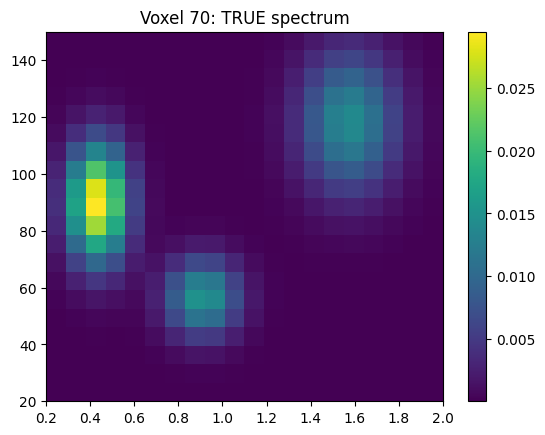

In [11]:
v = 70
w_v = W_true[:, v]
print("True weights for this voxel:", w_v)
print("True compartment (D,T2):", list(zip(D_means, T2_means)))

f_true_v = C_true @ w_v
f_true_v = f_true_v / f_true_v.sum()

plt.imshow(f_true_v.reshape(nD, nT2).T, origin='lower', aspect='auto',
           extent=[D_vals[0], D_vals[-1], T2_vals[0], T2_vals[-1]])
plt.colorbar(); plt.title(f'Voxel {v}: TRUE spectrum')
plt.show()


## Compare Initialisation Methods

This experiment compares four initialisation strategies for the optimisation:

- **GT:** uses the true compartment matrix and is an oracle reference.
- **Lstsq:** uses a data-driven least-squares initialisation without clustering.
- **NNLS:** uses non-negative least-squares spectrum fitting followed by clustering.
- **MADCO:** uses marginal-constrained spectrum fitting followed by clustering.

In this first comparison, `sigma2` and `lambda` remain fixed during optimisation. The later comparison repeats the same methods while updating both parameters at each iteration.

In [12]:
n_iter = 300

alpha_init = 5.0

C_small_init_gt = np.diag(s) @ V_mat.T @ C_true
lam_init_gt = define_initial_lambda(C_small_init_gt, R, K)
W_est_gt, _, C_small_est_gt, alpha_est_gt, *_ = run_optimisation(
    Y, U, C_small_init_gt, M0_true, K, R, eps, n_iter, sigma2_true, alpha_init, lam_init_gt, W0,
    bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True, verbose_every=n_iter + 1,
)

C_small_init_lstsq = define_initial_C_small(Y, U, W0, M0_true, K)
lam_init_lstsq = define_initial_lambda(C_small_init_lstsq, R, K)
W_est_lstsq, _, C_small_est_lstsq, alpha_est_lstsq, *_ = run_optimisation(
    Y, U, C_small_init_lstsq, M0_true, K, R, eps, n_iter, sigma2_true, alpha_init, lam_init_lstsq, W0,
    bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True, verbose_every=n_iter + 1,
)

C_small_init_nnls = define_initial_C_small_NNLS(
    Y, A, s, V_mat, voxel_idx, K, D_vals, T2_vals, Dmin, Dmax, T2min, T2max, nD, nT2,
)
lam_init_nnls = define_initial_lambda(C_small_init_nnls, R, K)
W_est_nnls, _, C_small_est_nnls, alpha_est_nnls, *_ = run_optimisation(
    Y, U, C_small_init_nnls, M0_true, K, R, eps, n_iter, sigma2_true, alpha_init, lam_init_nnls, W0,
    bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True, verbose_every=n_iter + 1,
)


C_small_init_madco = define_initial_C_small_MADCO(
    Y, A, s, V_mat, voxel_idx, K, D_vals, T2_vals, b_vals, TE_vals,
    Dmin, Dmax, T2min, T2max, nB, nTE, nD, nT2,
)
lam_init_madco = define_initial_lambda(C_small_init_madco, R, K)
W_est_madco, _, C_small_est_madco, alpha_est_madco, *_ = run_optimisation(
    Y, U, C_small_init_madco, M0_true, K, R, eps, n_iter, sigma2_true, alpha_init, lam_init_madco, W0,
    bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True, verbose_every=n_iter + 1,
)

print(f"{'method':10s} {'W_mae':>8s} {'C_mae':>8s} {'alpha_est':>10s}")
for name, W_est_, C_small_est_, alpha_est_ in [
    ("GT",     W_est_gt,    C_small_est_gt,    alpha_est_gt),
    ("Lstsq",  W_est_lstsq, C_small_est_lstsq, alpha_est_lstsq),
    ("NNLS",   W_est_nnls,  C_small_est_nnls,  alpha_est_nnls),
    ("MADCO",  W_est_madco, C_small_est_madco, alpha_est_madco),
]:
    W_mae, C_mae = matched_errors(C_small_true, C_small_est_, W_true, W_est_)
    print(f"{name:10s} {W_mae:8.4f} {C_mae:8.4f} {alpha_est_:10.2f}")


iter 0: loss=59578.0479, fit_err=0.478404, sigma2=0.000004, lam=0.7751, alpha=1.5264
iter 0: loss=3020969.8306, fit_err=24.173878, sigma2=0.000004, lam=0.9097, alpha=0.2991
iter 0: loss=75850.4188, fit_err=0.608359, sigma2=0.000004, lam=0.7867, alpha=1.2093
iter 0: loss=1404162.9803, fit_err=11.235031, sigma2=0.000004, lam=0.8785, alpha=0.8137
method        W_mae    C_mae  alpha_est
GT           0.0045   0.0054       1.64
Lstsq        0.0337   0.0286       1.77
NNLS         0.0393   0.0240       1.78
MADCO        0.1149   0.1527       2.67



GT


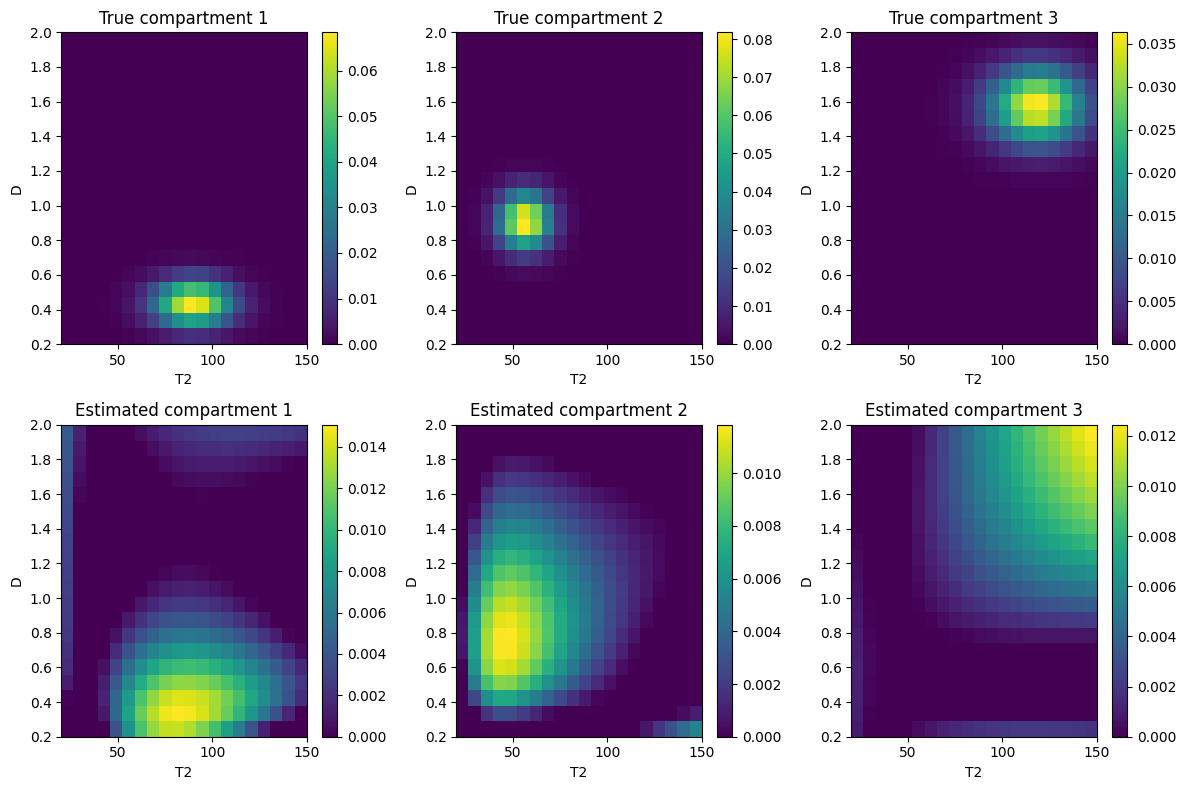

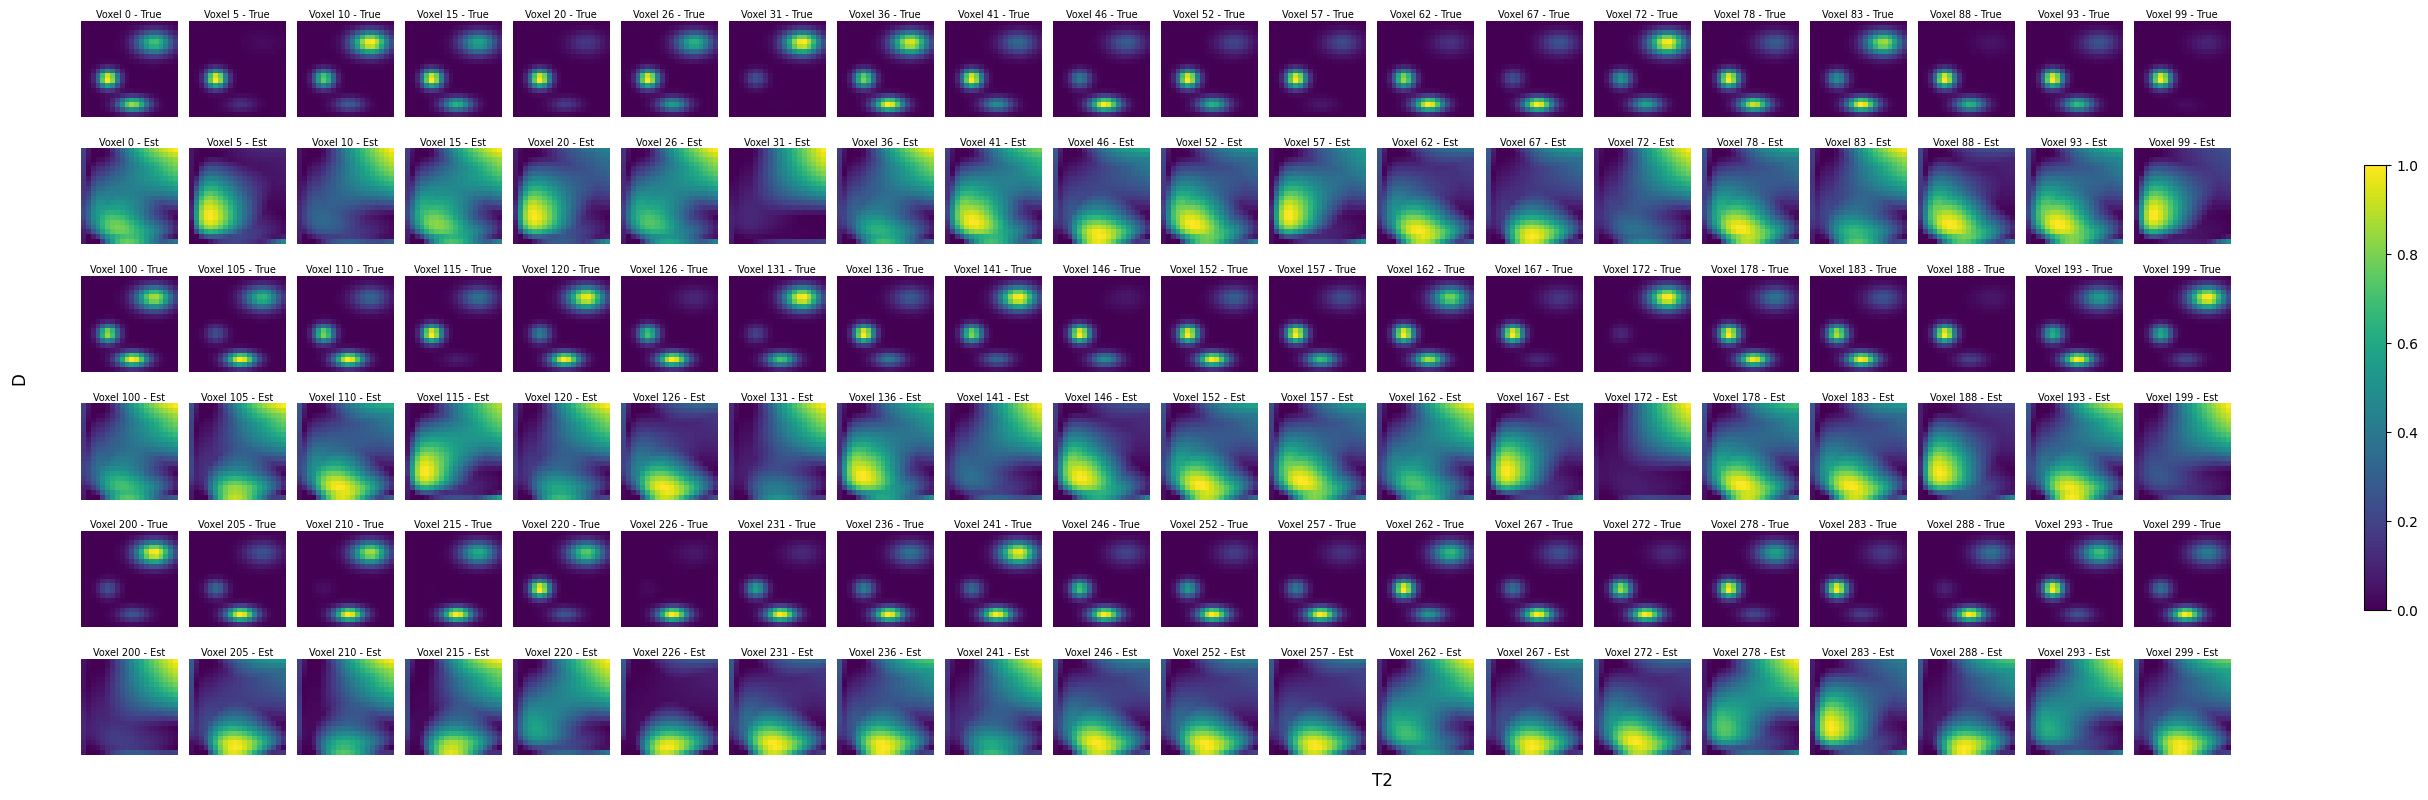


Lstsq


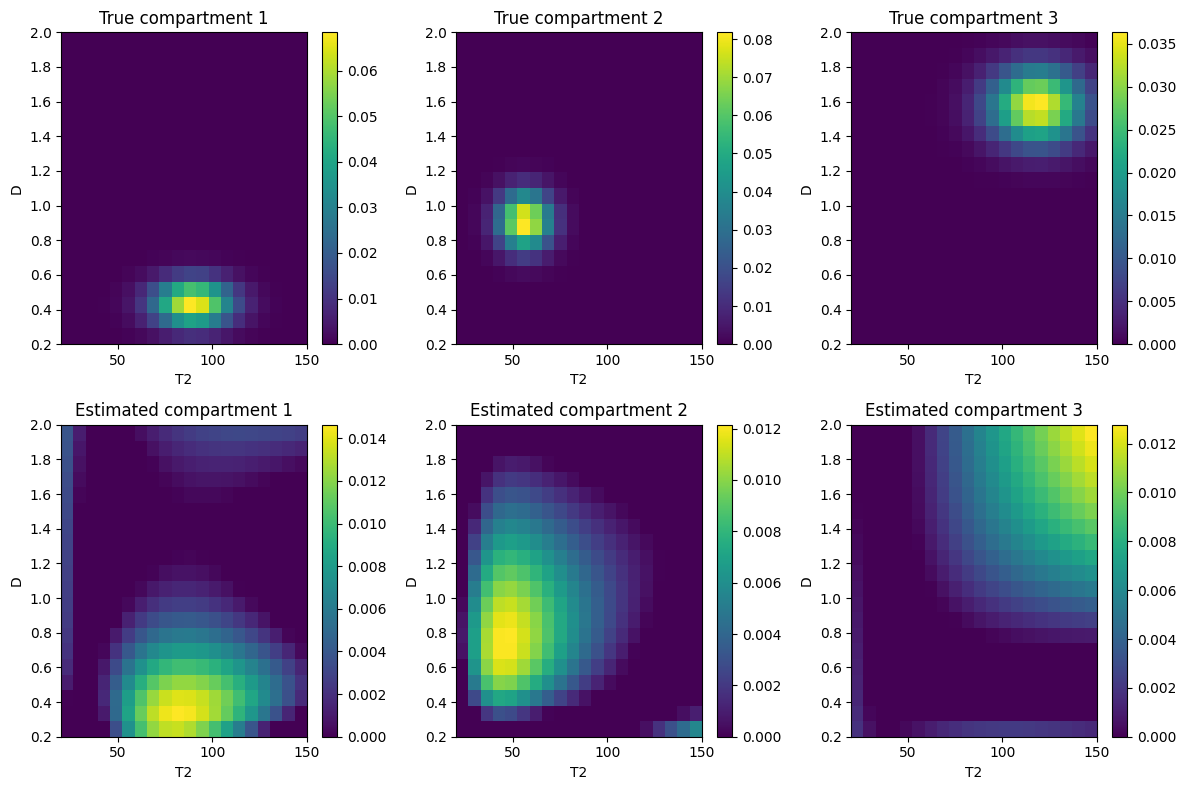

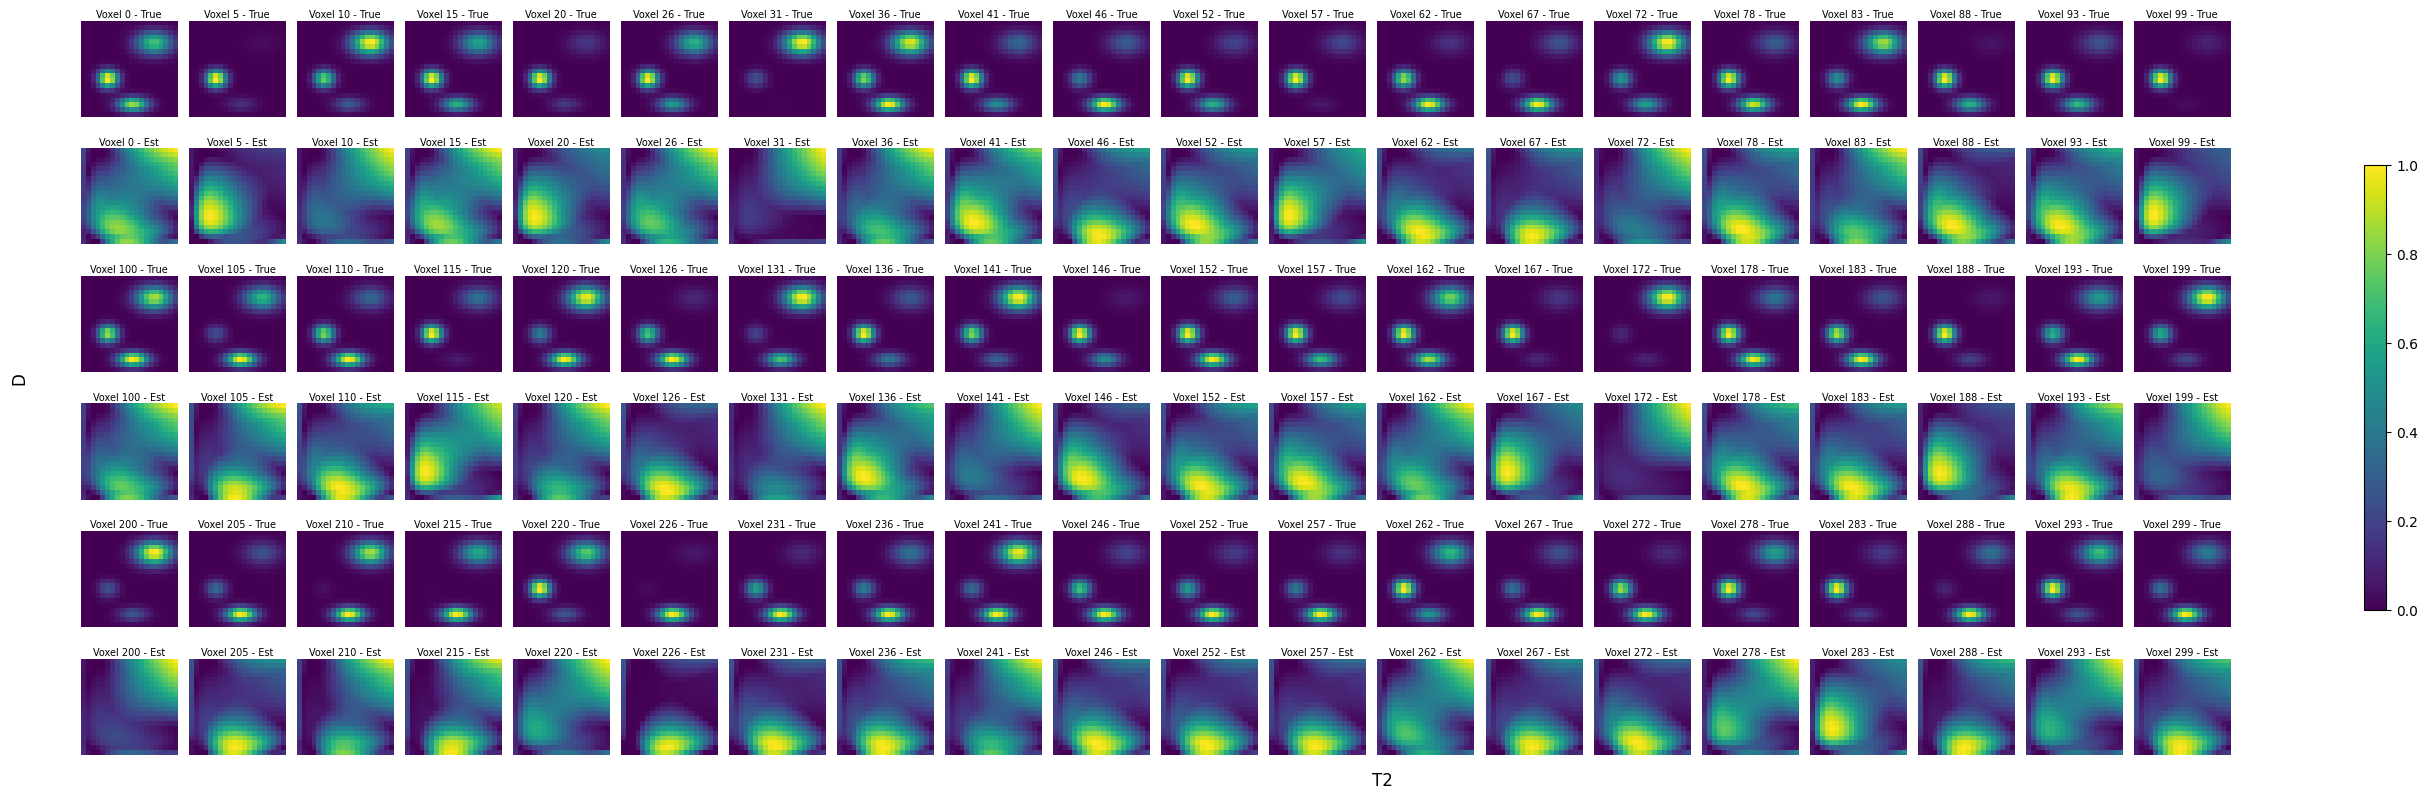


NNLS


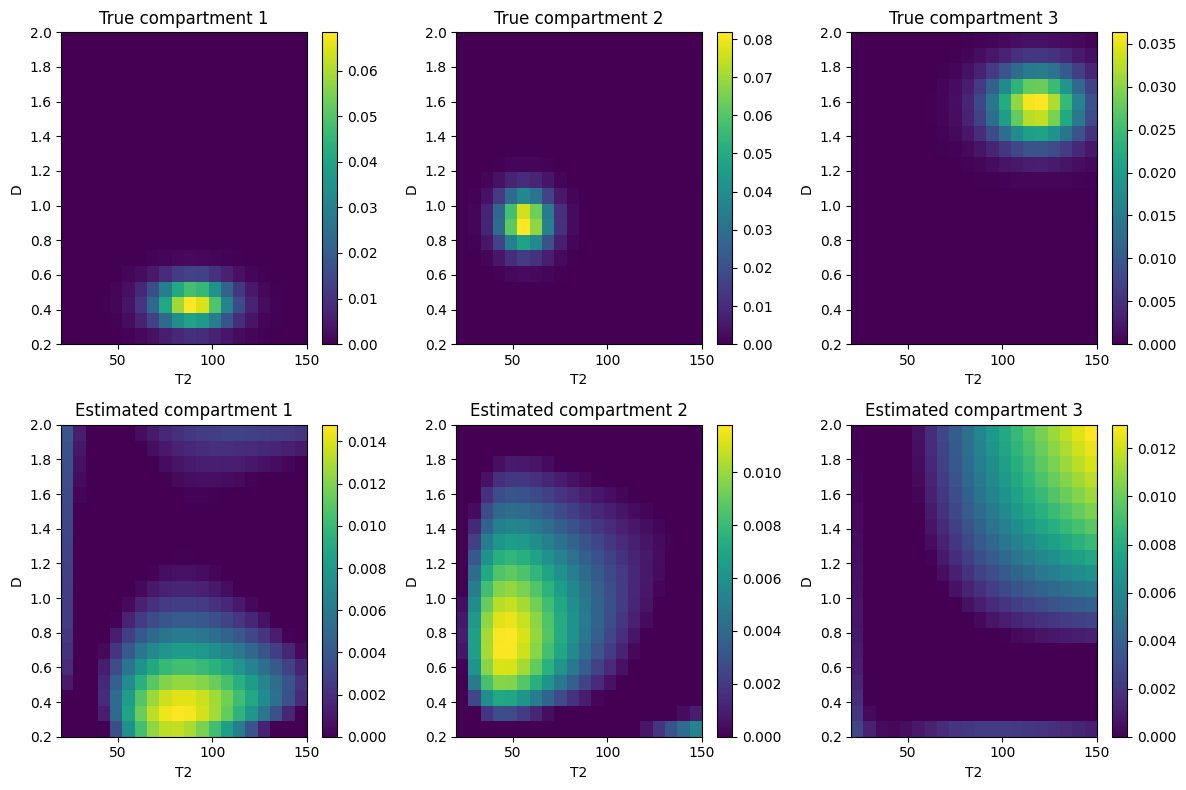

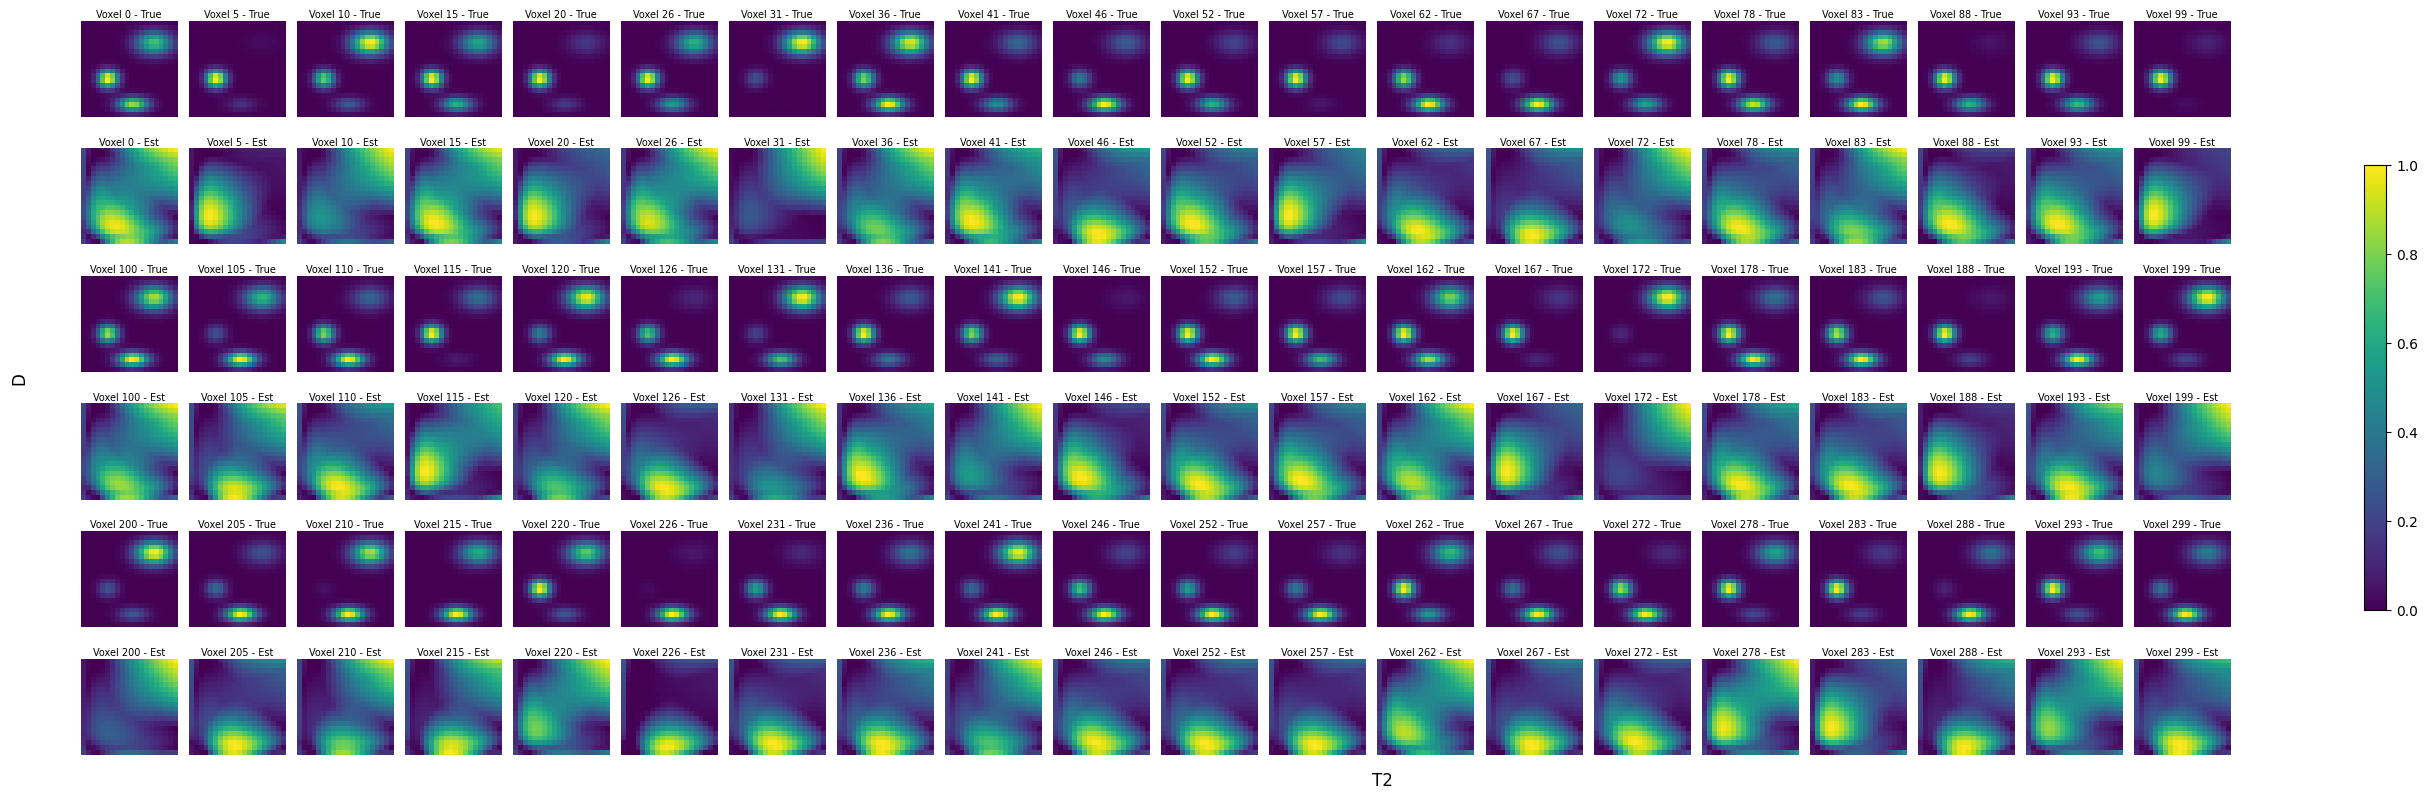


MADCO


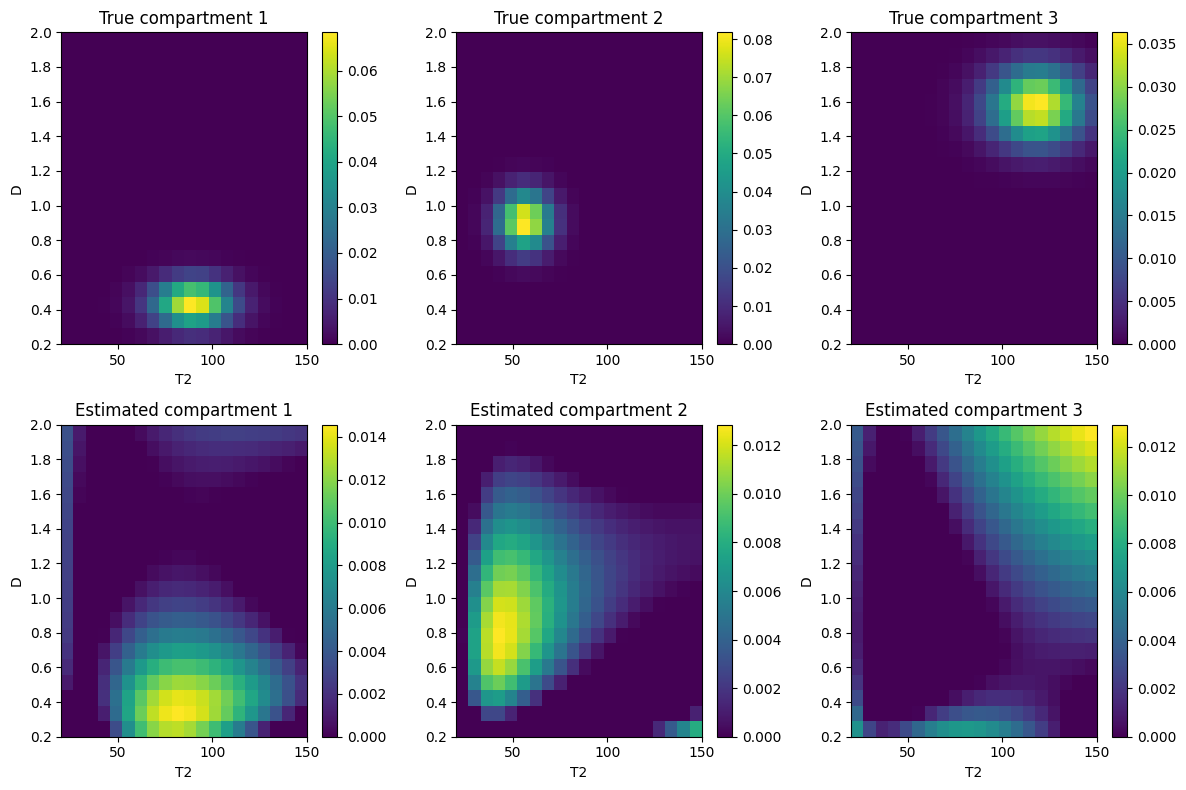

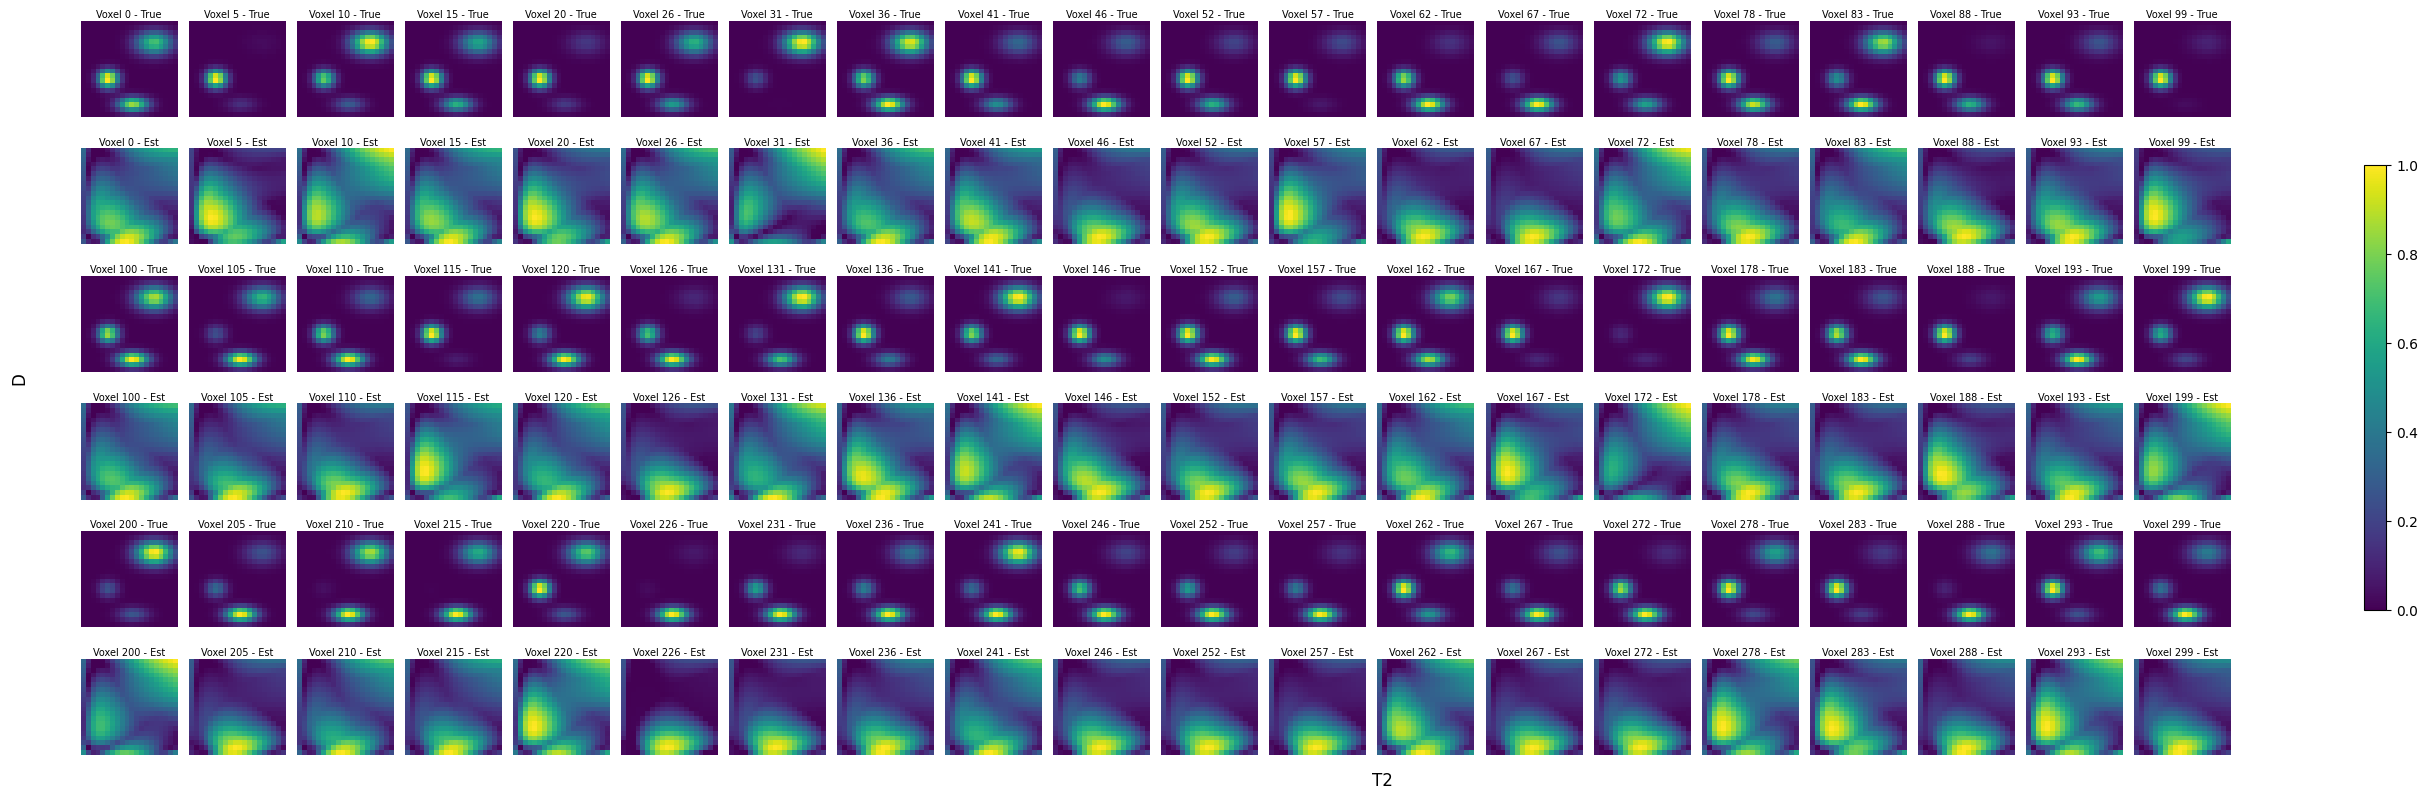

In [13]:
results = [
    ("GT",    C_small_est_gt,    W_est_gt),
    ("Lstsq", C_small_est_lstsq, W_est_lstsq),
    ("NNLS",  C_small_est_nnls,  W_est_nnls),
    ("MADCO", C_small_est_madco, W_est_madco),
]

for name, C_small_est_, W_est_ in results:
    print(f"\n{name}")
    C_est_ = estimate_C(V_mat, s, C_small_est_)

    plot_compartment_comparison(C_true, C_est_, K, nD, nT2, D_vals, T2_vals)
    plot_voxel_grid_comparison(C_true, W_true, C_est_, W_est_, K, n_voxels, nD, nT2)


In [14]:
n_iter = 300
alpha_init = 5.0

C_small_init_gt = np.diag(s) @ V_mat.T @ C_true
lam_init_gt = define_initial_lambda(C_small_init_gt, R, K)
W_est_gt, _, C_small_est_gt, alpha_est_gt, *_ = run_optimisation(
    Y, U, C_small_init_gt, M0_true, K, R, eps, n_iter, sigma2_true, alpha_init, lam_init_gt, W0,
    bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True,
    update_sigma2_flag=True, update_lambda_flag=True,
    verbose_every=n_iter + 1,
)

C_small_init_lstsq = define_initial_C_small(Y, U, W0, M0_true, K)
lam_init_lstsq = define_initial_lambda(C_small_init_lstsq, R, K)
W_est_lstsq, _, C_small_est_lstsq, alpha_est_lstsq, *_ = run_optimisation(
    Y, U, C_small_init_lstsq, M0_true, K, R, eps, n_iter, sigma2_true, alpha_init, lam_init_lstsq, W0,
    bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True,
    update_sigma2_flag=True, update_lambda_flag=True,
    verbose_every=n_iter + 1,
)


C_small_init_nnls = define_initial_C_small_NNLS(
    Y, A, s, V_mat, voxel_idx, K, D_vals, T2_vals, Dmin, Dmax, T2min, T2max, nD, nT2,
)
lam_init_nnls = define_initial_lambda(C_small_init_nnls, R, K)
W_est_nnls, _, C_small_est_nnls, alpha_est_nnls, *_ = run_optimisation(
    Y, U, C_small_init_nnls, M0_true, K, R, eps, n_iter, sigma2_true, alpha_init, lam_init_nnls, W0,
    bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True,
    update_sigma2_flag=True, update_lambda_flag=True,
    verbose_every=n_iter + 1,
)


C_small_init_madco = define_initial_C_small_MADCO(
    Y, A, s, V_mat, voxel_idx, K, D_vals, T2_vals, b_vals, TE_vals,
    Dmin, Dmax, T2min, T2max, nB, nTE, nD, nT2,
)
lam_init_madco = define_initial_lambda(C_small_init_madco, R, K)
W_est_madco, _, C_small_est_madco, alpha_est_madco, *_ = run_optimisation(
    Y, U, C_small_init_madco, M0_true, K, R, eps, n_iter, sigma2_true, alpha_init, lam_init_madco, W0,
    bound_eps=1e-2, update_alpha_flag=True, update_W_flag=True,
    update_M0_flag=False, update_C_flag=True,
    update_sigma2_flag=True, update_lambda_flag=True,
    verbose_every=n_iter + 1,
)


print(f"{'method':10s} {'W_mae':>8s} {'C_mae':>8s} {'alpha_est':>10s}")
for name, W_est_, C_small_est_, alpha_est_ in [
    ("GT",     W_est_gt,    C_small_est_gt,    alpha_est_gt),
    ("Lstsq",  W_est_lstsq, C_small_est_lstsq, alpha_est_lstsq),
    ("NNLS",   W_est_nnls,  C_small_est_nnls,  alpha_est_nnls),
    ("MADCO",  W_est_madco, C_small_est_madco, alpha_est_madco),
]:
    W_mae, C_mae = matched_errors(C_small_true, C_small_est_, W_true, W_est_)
    print(f"{name:10s} {W_mae:8.4f} {C_mae:8.4f} {alpha_est_:10.2f}")


iter 0: loss=59777.4841, fit_err=0.478404, sigma2=0.000004, lam=0.7750, alpha=1.5264
iter 0: loss=59235.2707, fit_err=24.173878, sigma2=0.000201, lam=0.9196, alpha=0.2991
iter 0: loss=59805.4660, fit_err=0.608359, sigma2=0.000005, lam=0.7850, alpha=1.2093
iter 0: loss=59783.1389, fit_err=11.235031, sigma2=0.000094, lam=0.8281, alpha=0.8137
method        W_mae    C_mae  alpha_est
GT           0.0045   0.0054       1.64
Lstsq        0.0337   0.0286       1.77
NNLS         0.0393   0.0240       1.78
MADCO        0.1149   0.1526       2.67



GT


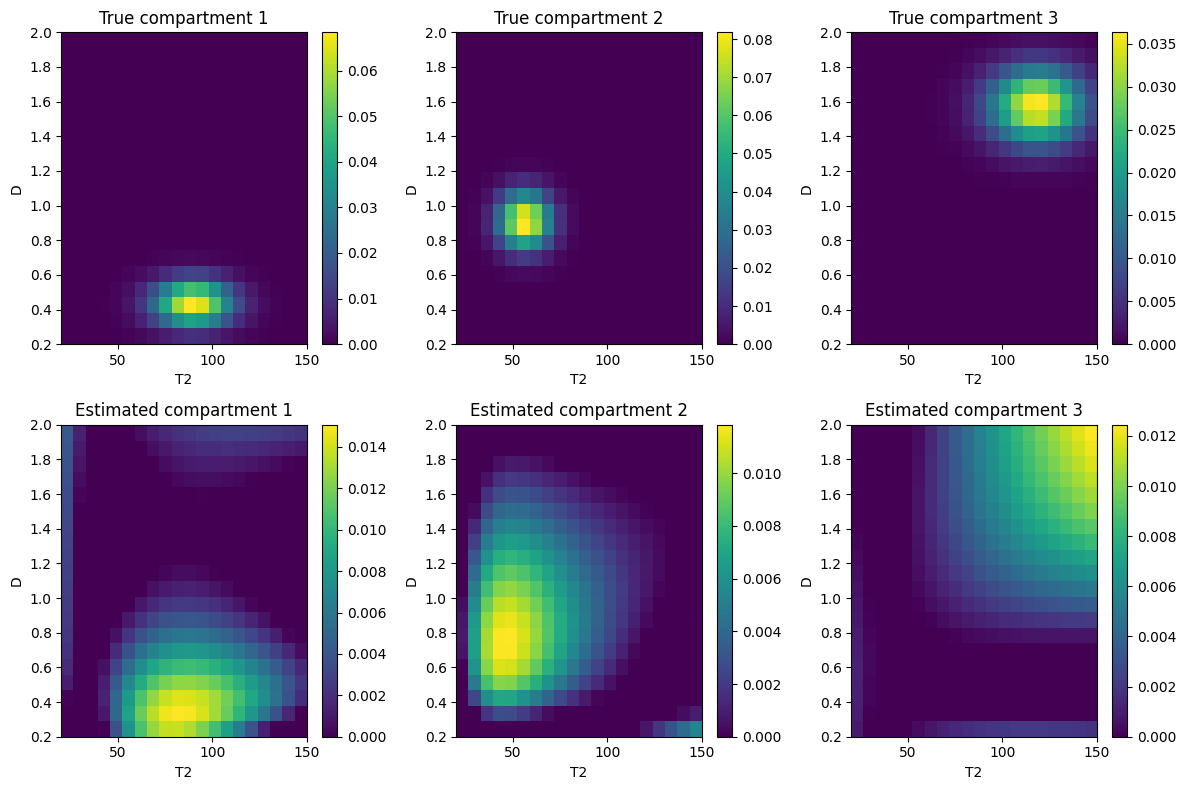

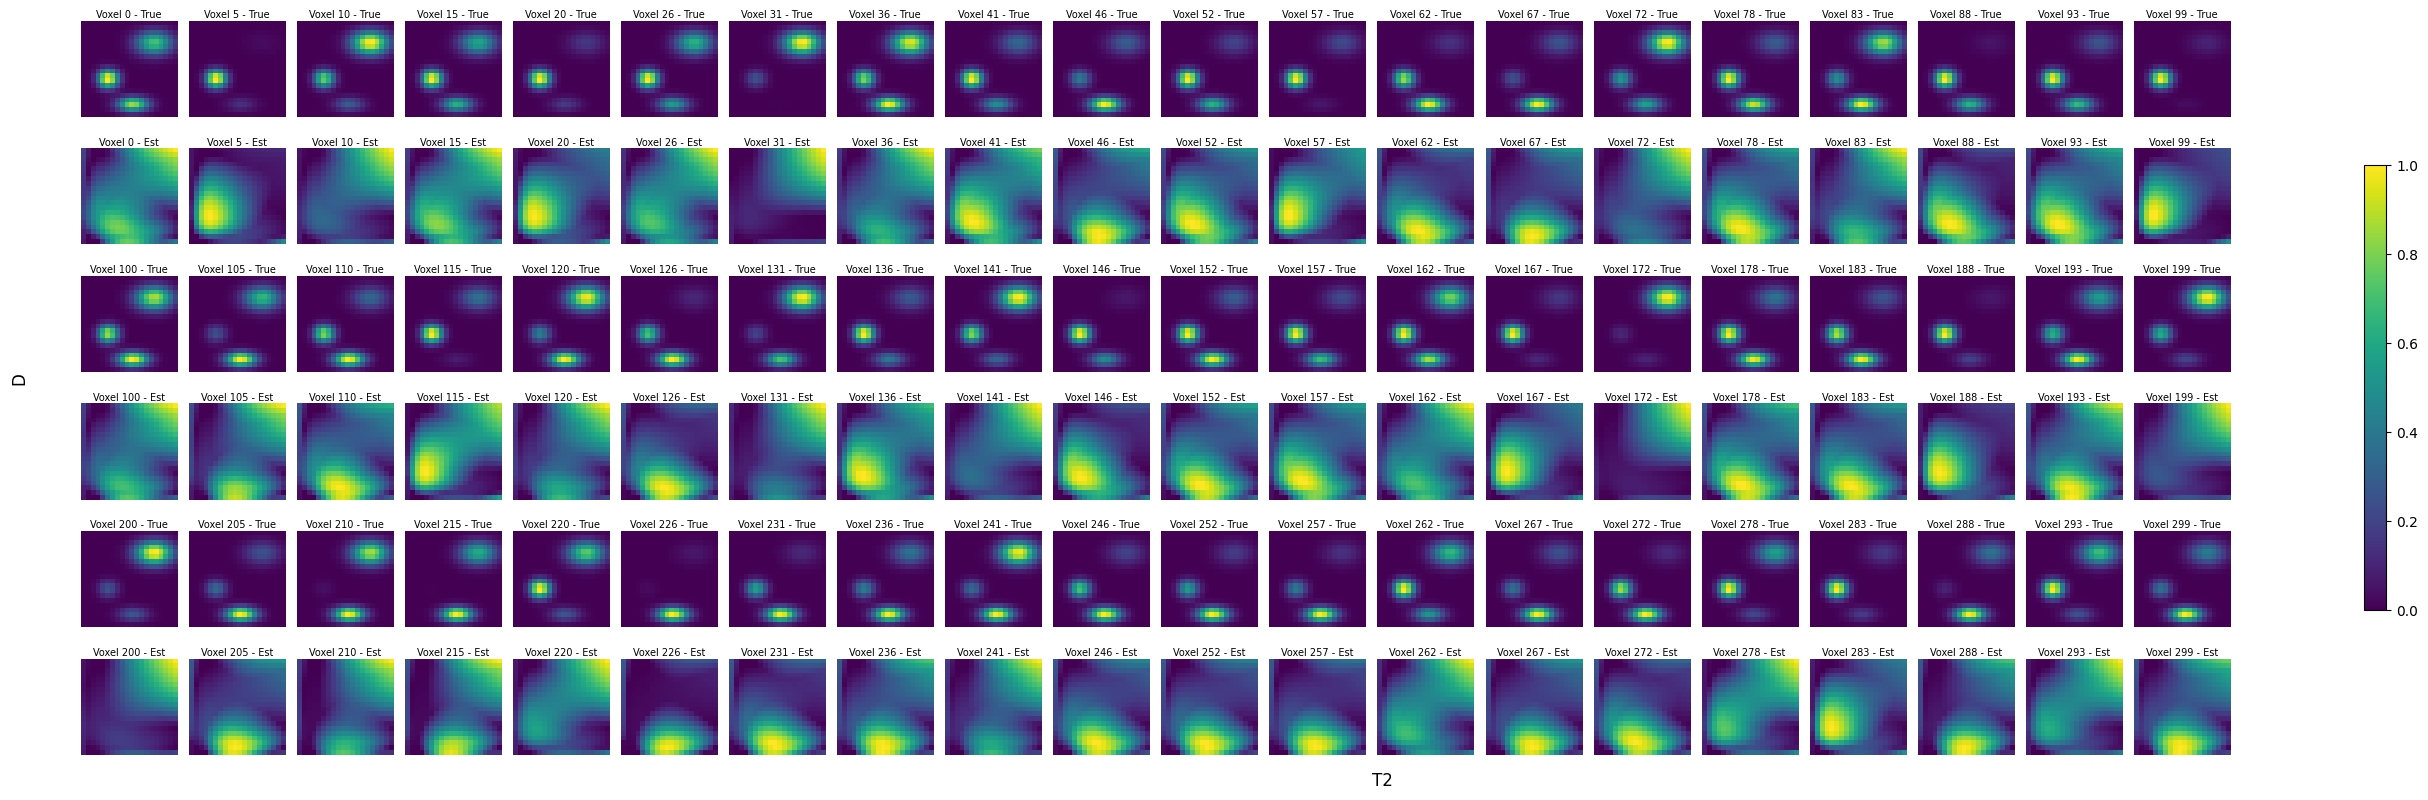


Lstsq


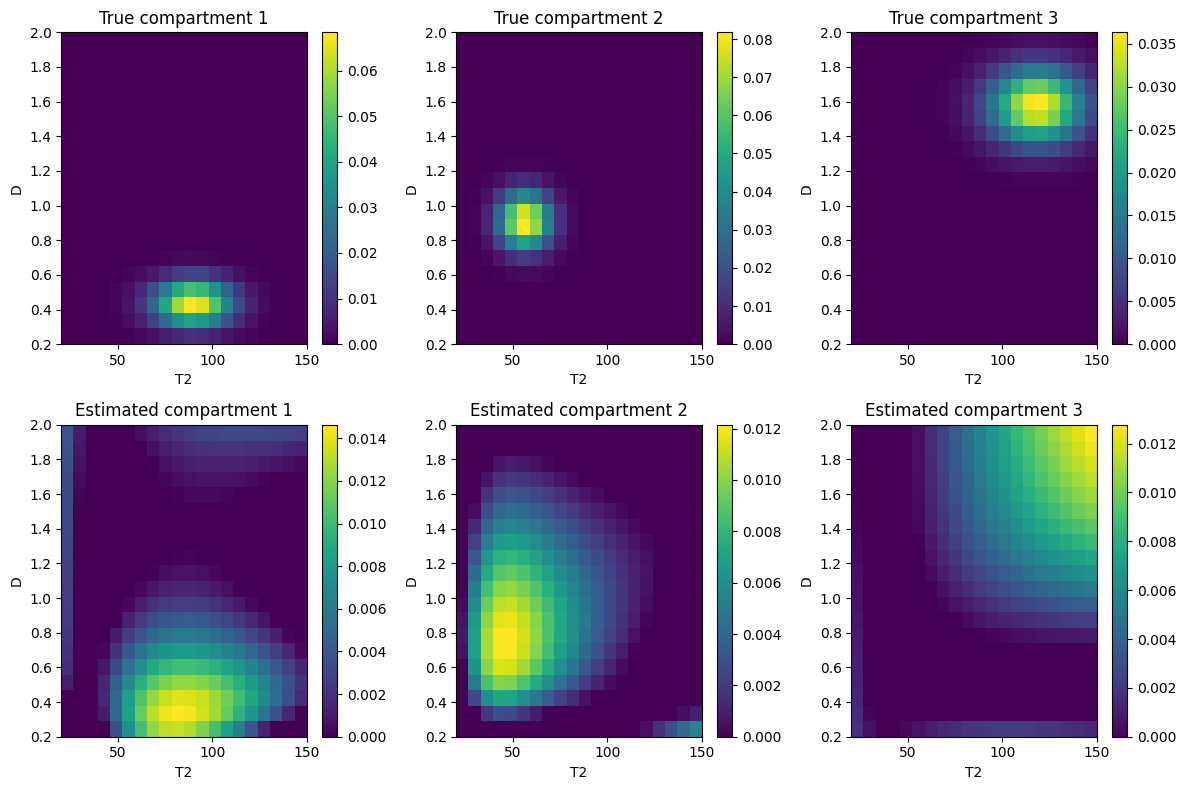

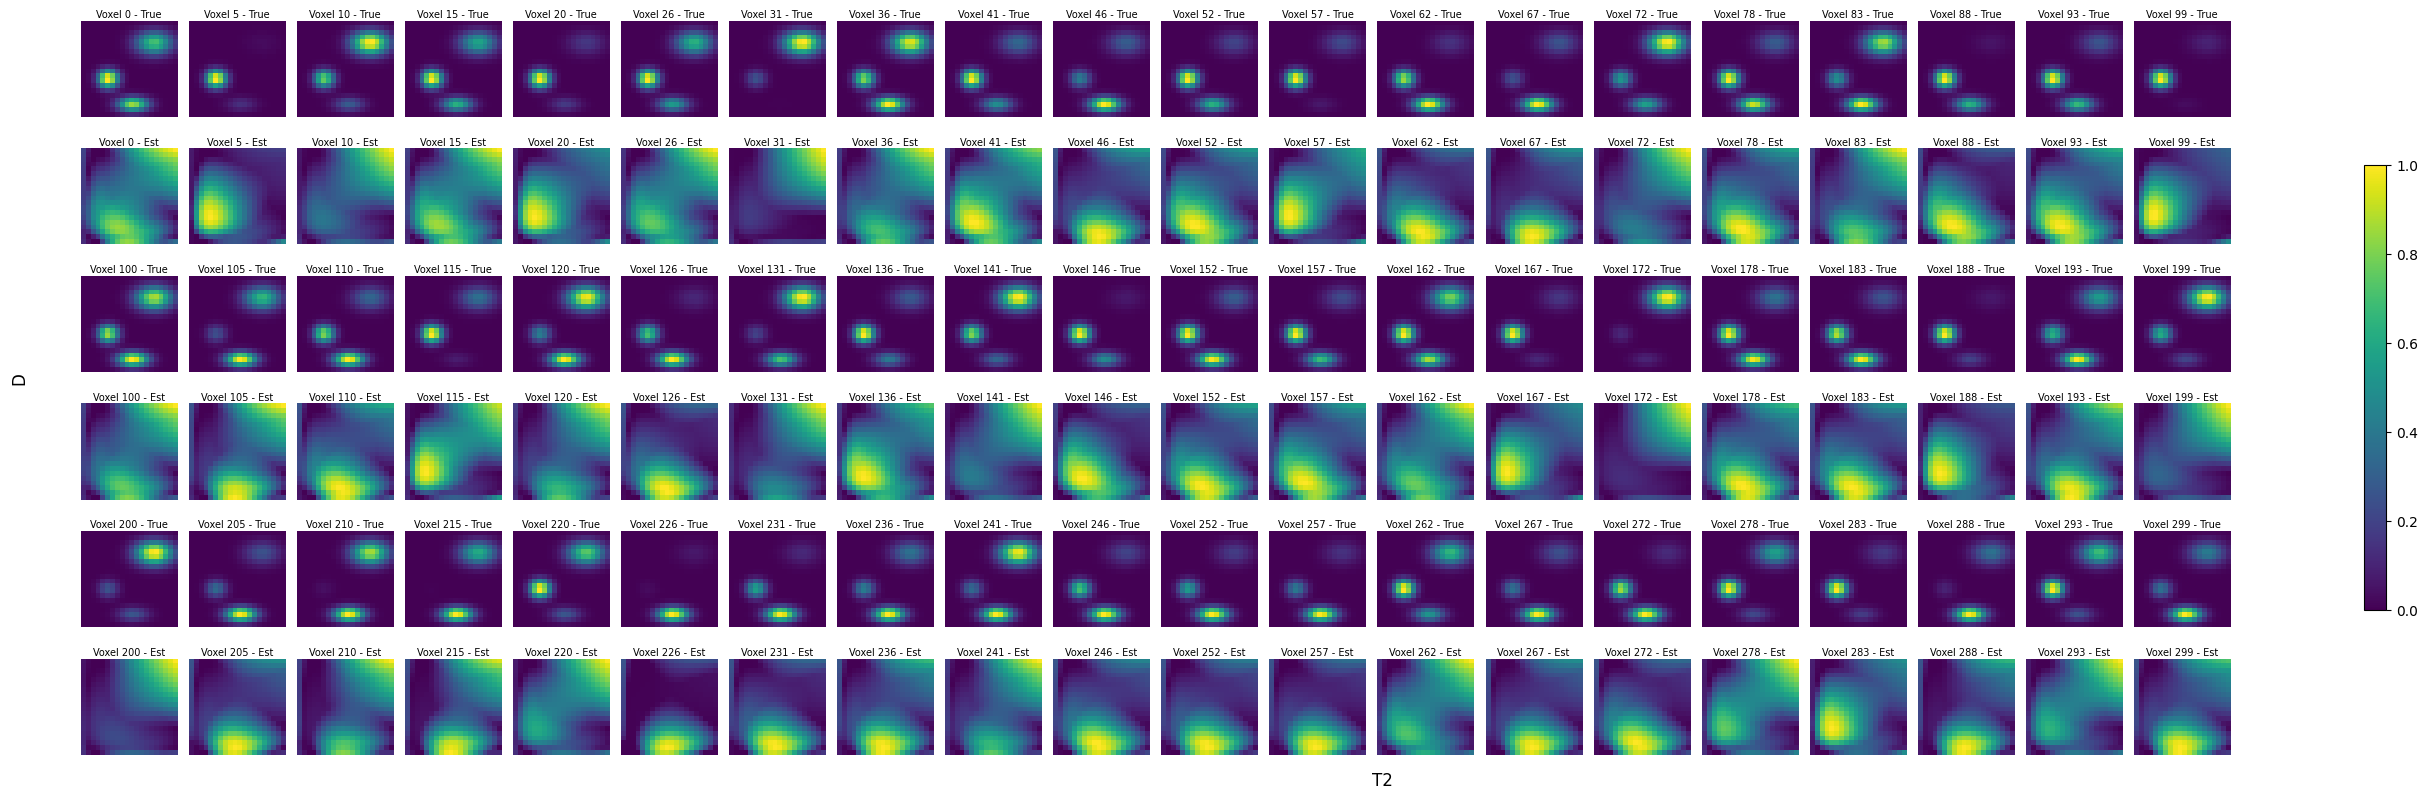


NNLS


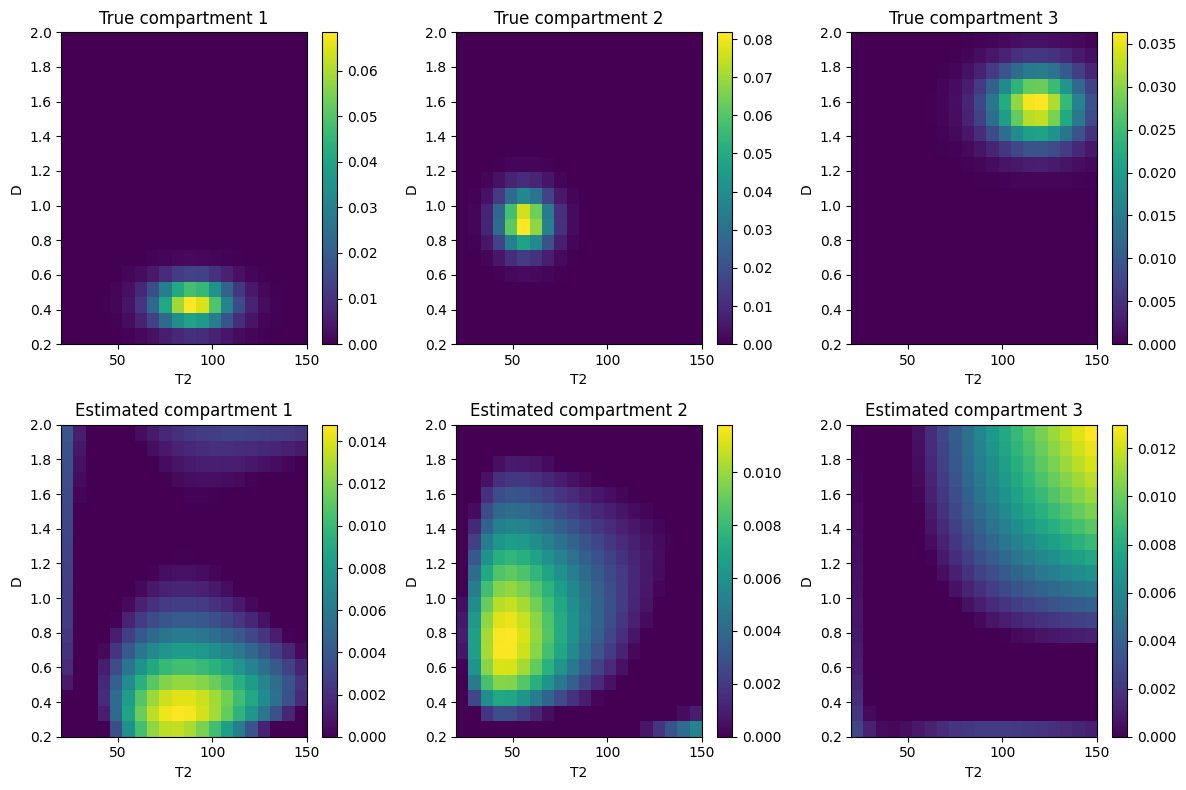

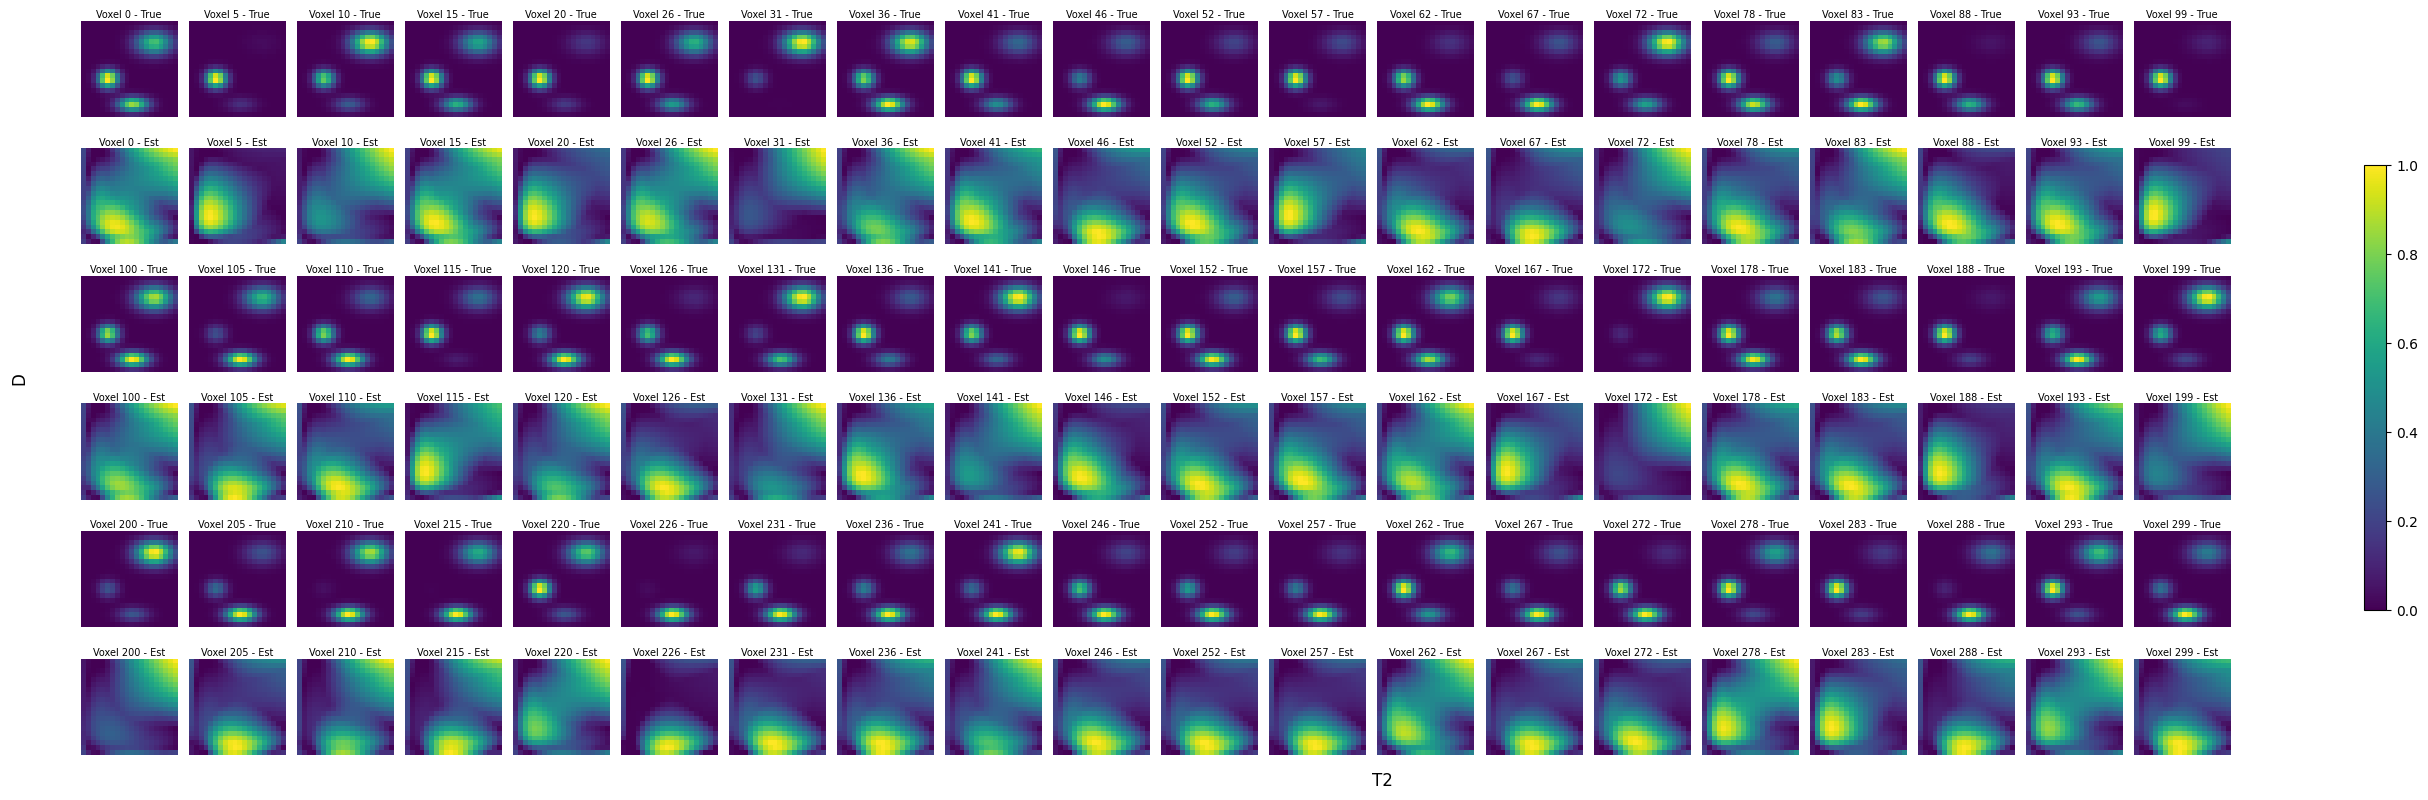


MADCO


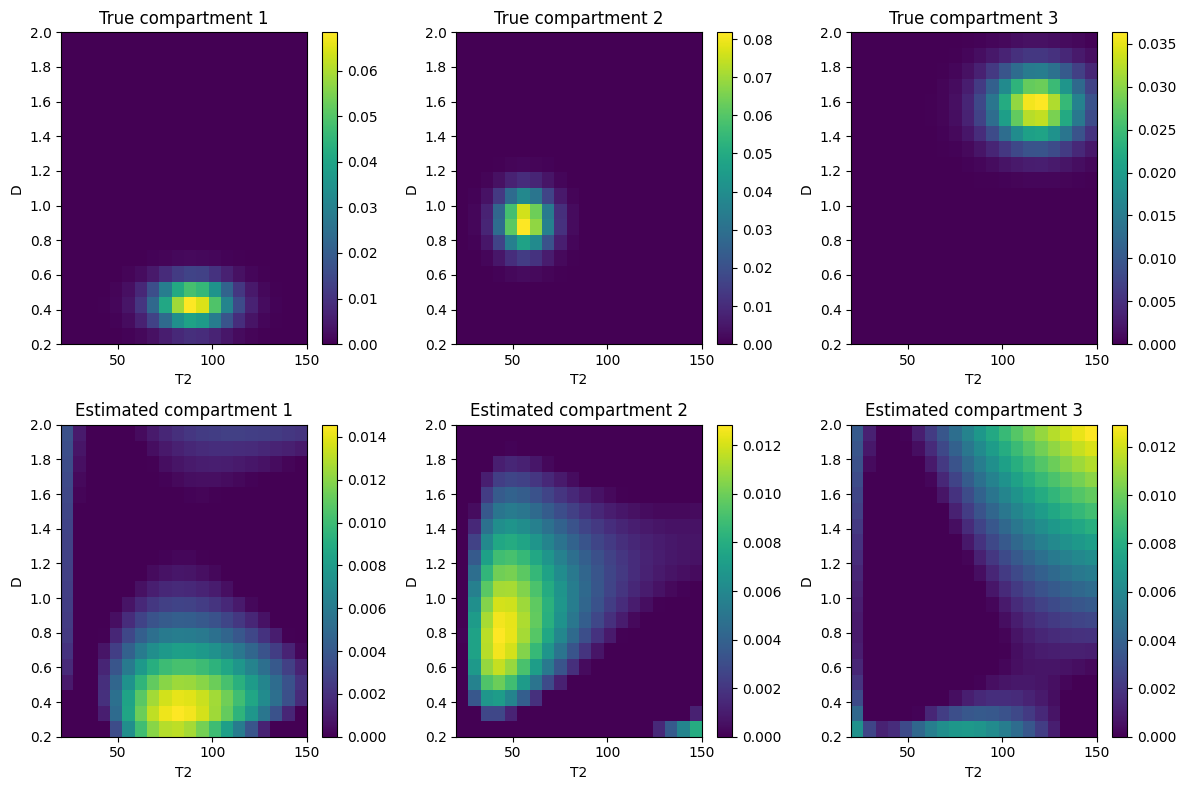

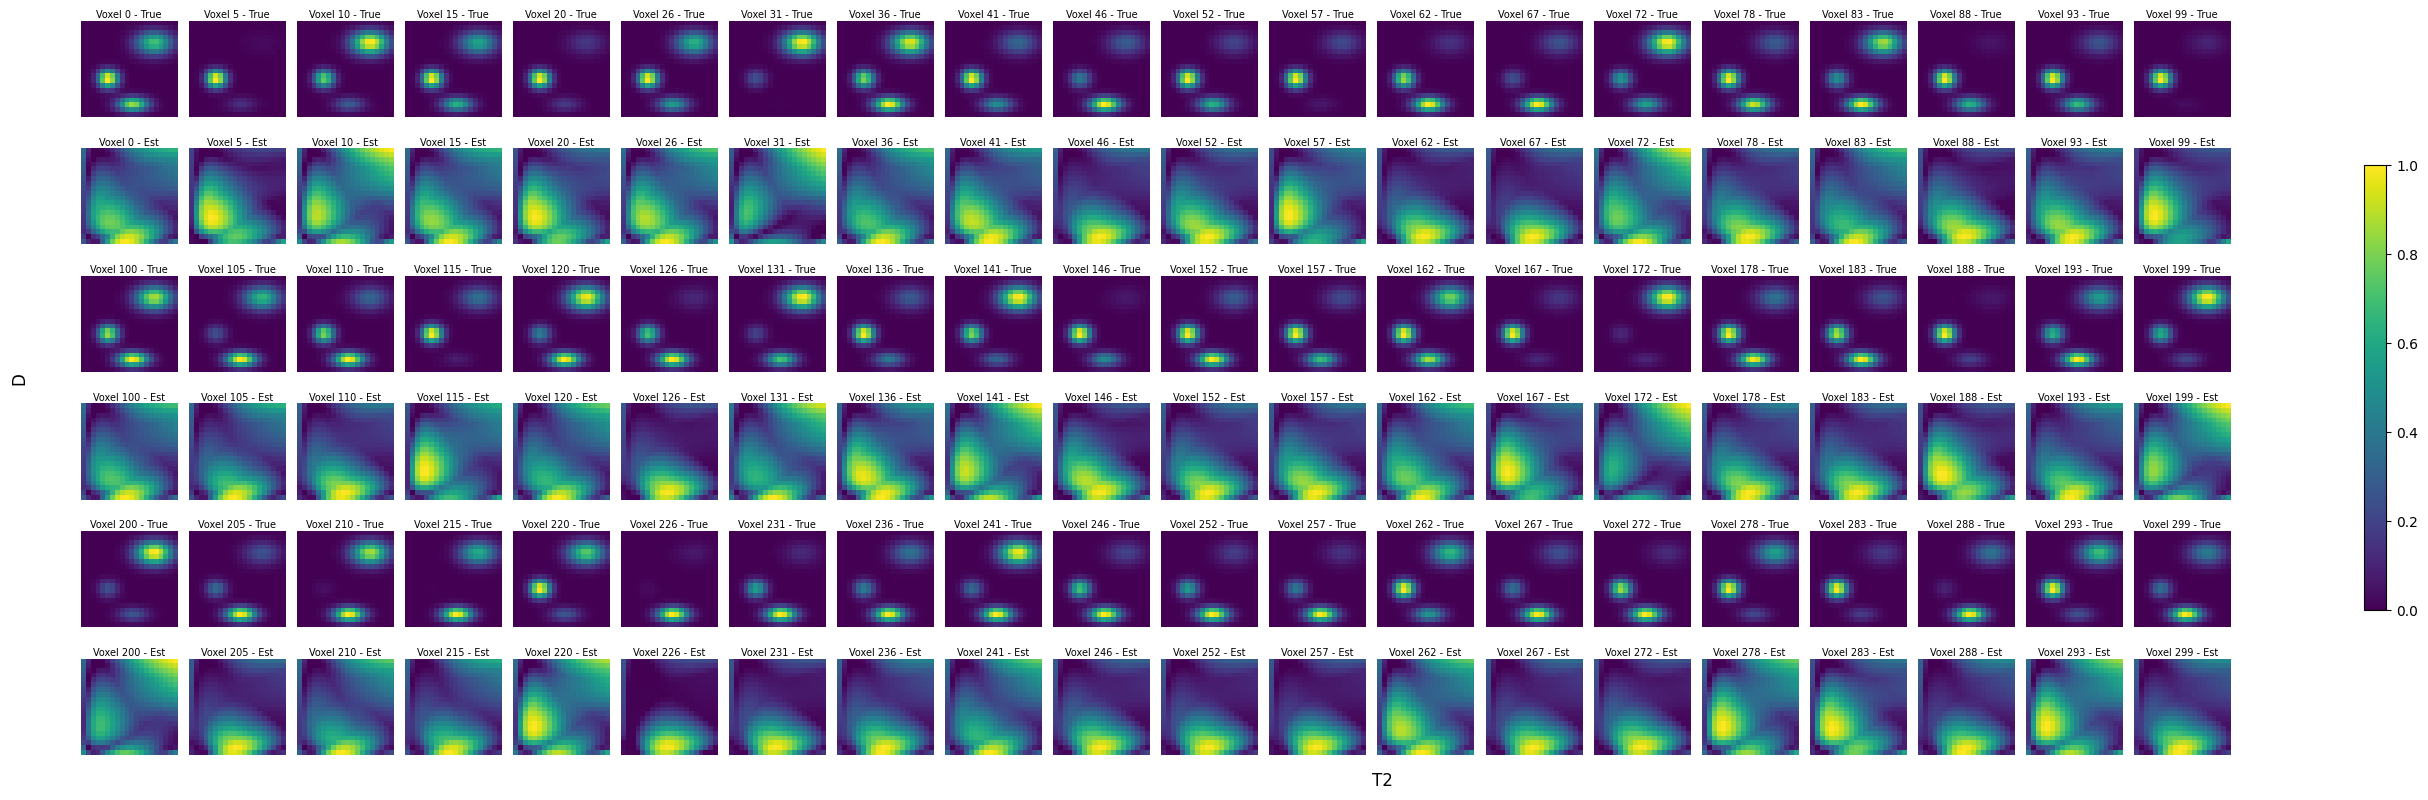

In [15]:

results = [
    ("GT",    C_small_est_gt,    W_est_gt),
    ("Lstsq", C_small_est_lstsq, W_est_lstsq),
    ("NNLS",  C_small_est_nnls,  W_est_nnls),
    ("MADCO", C_small_est_madco, W_est_madco),
]

for name, C_small_est_, W_est_ in results:
    print(f"\n{name}")
    C_est_ = estimate_C(V_mat, s, C_small_est_)

    plot_compartment_comparison(C_true, C_est_, K, nD, nT2, D_vals, T2_vals)
    plot_voxel_grid_comparison(C_true, W_true, C_est_, W_est_, K, n_voxels, nD, nT2)


Notes on these results
- NNLS and MADCO build their starting C from only 7 voxels (`voxel_idx`). Averaging so few spectra is noisy, so the k-means step can misplace the compartments. The weaker MADCO result probably reflects this rather than MADCO itself; a larger voxel subset would give a fairer comparison.
- Updating σ² and λ as well (second table) gives practically the same results as keeping them fixed, so the method is not sensitive to estimating them here.